<a href="https://colab.research.google.com/github/vicha1234/TelcoChurnPrediction/blob/main/2425610.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [536]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization


**Load the data set**

In [537]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Perform EDA**

In [538]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [539]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [540]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [541]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [542]:
df.shape

(7043, 21)

In [543]:
telco=df['Churn']
telco

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [323]:
print(telco.isnull().sum())

0


In [324]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [325]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [326]:
df.shape

(7043, 21)

In [339]:
# Select numeric columns (exclude Churn for now)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation
numeric_corr = numeric_df.corr()

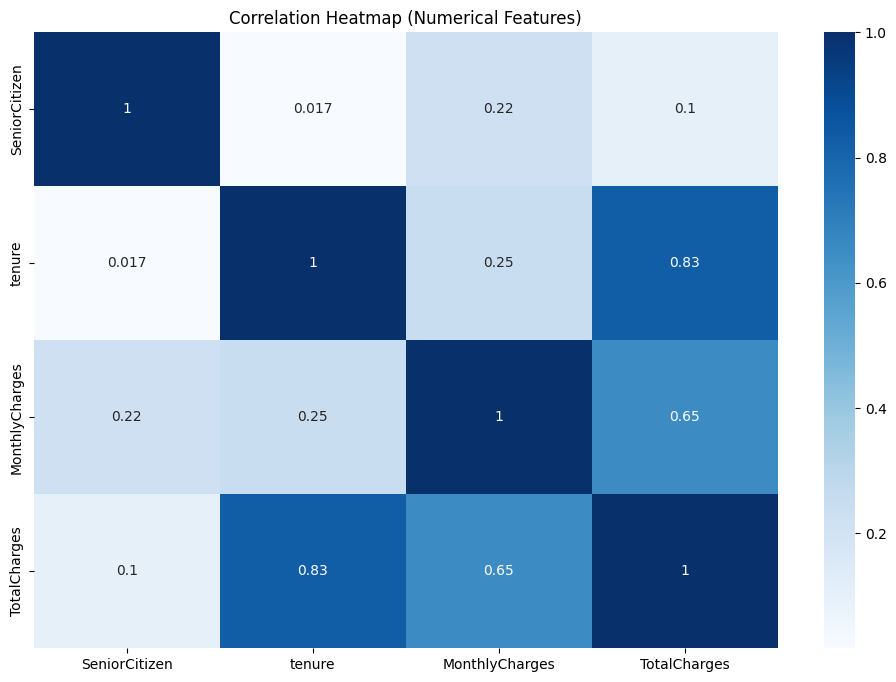

In [340]:
#HEATMAP (NUMERICAL CORRELATION)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [341]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**EDA Visualization**

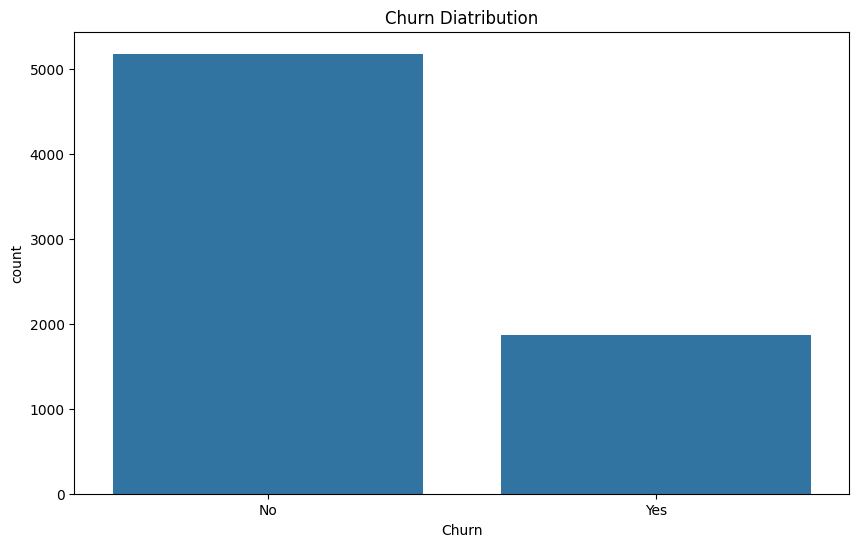

,proportion
Churn,
No,0.73463
Yes,0.26537


In [342]:
plt.figure(figsize=(10,6))
sns.countplot(x='Churn',data=df)
plt.title('Churn Diatribution')
plt.show()

df['Churn'].value_counts(normalize=True)

The dataset is imbalanced.Arount 26% customer churn and around 74% customer stay.(The dataset is imbalanced with 26% churn and 74% non-churn.)

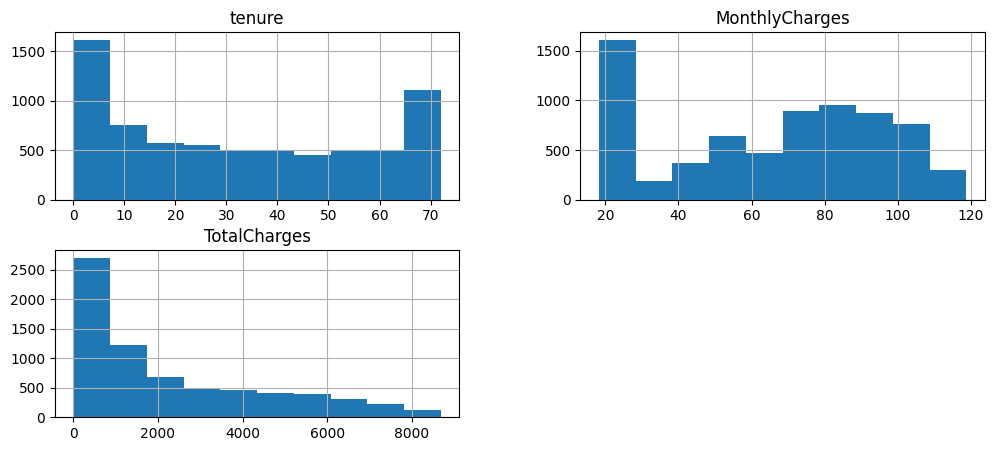

In [343]:
df[['tenure','MonthlyCharges','TotalCharges']].hist(figsize=(12,5))
plt.show()

Tenure distribution shows many customers are relatively new,which may relate to high churn risk.MonthlyCharges has higher values concentrated for churned customers.

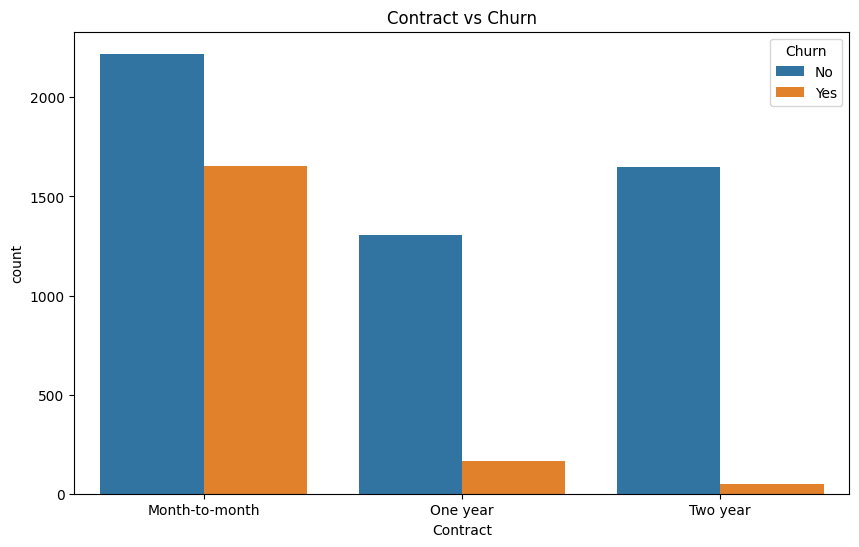

In [344]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('Contract vs Churn')
plt.xticks(rotation=0)
plt.show()

Month to month customers churn the most.One year and two year contract customers rarely churn.Contract length is a strong predictor of churn

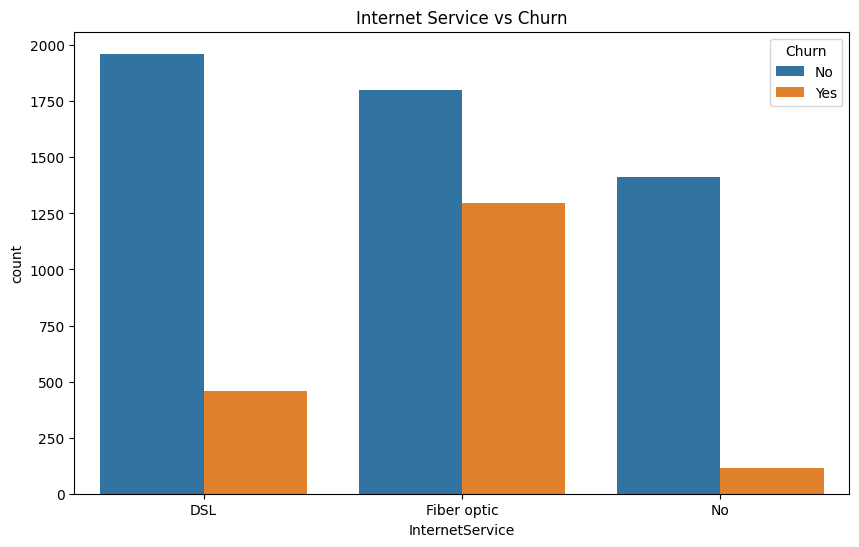

In [345]:
plt.figure(figsize=(10,6))
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title('Internet Service vs Churn')
plt.show()

Fiber optic customers show high churn.DSL and no internet customers churn less.

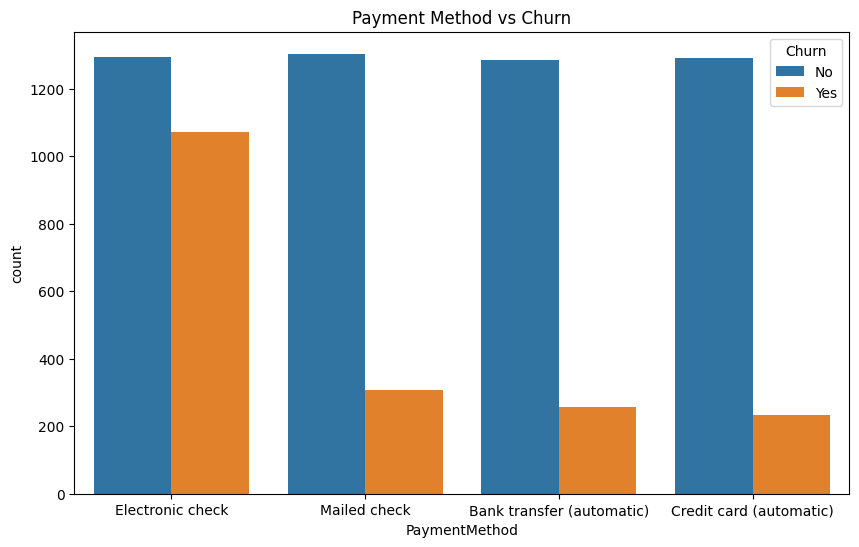

In [346]:
plt.figure(figsize=(10,6))
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=0)
plt.show()

Electronic check users churn the most.
Credit card users churn the least.

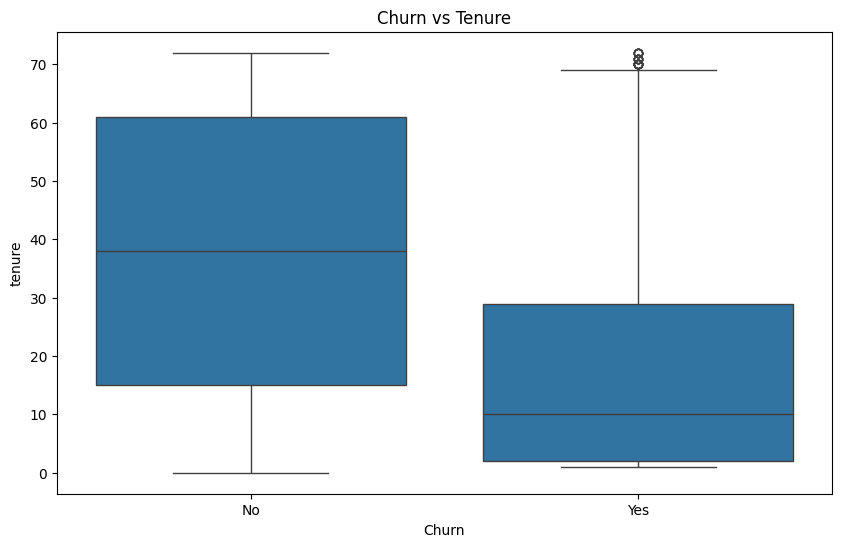

In [347]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title('Churn vs Tenure')
plt.show()

Churned customers generally have very low tenure.
Long term customers rarely churn.

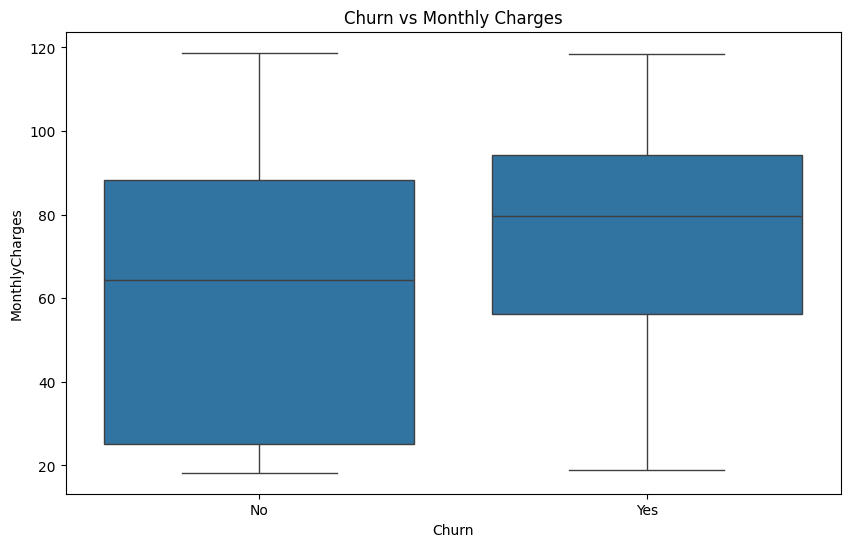

In [348]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Churn vs Monthly Charges')
plt.show()

Customers with higher monthly charges churn more.Low paying customers churn less.

# **Task 2 - Preprocessing Part**

In [349]:
df = df.drop('customerID', axis=1)

In [350]:
#CONVERT TARGET COLUMN
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

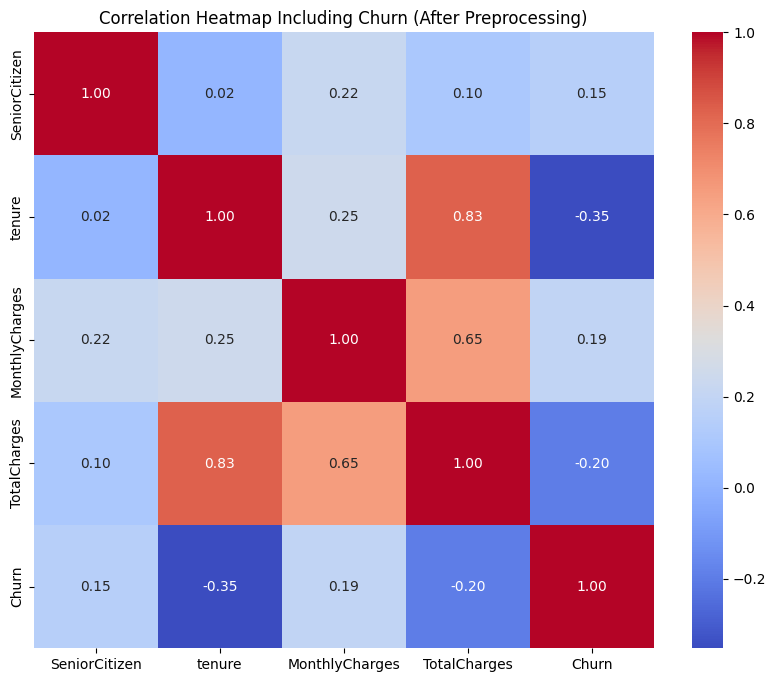

In [351]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap Including Churn (After Preprocessing)")
plt.show()

In [352]:
#Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing in TotalCharges BEFORE fill:", df['TotalCharges'].isnull().sum())

In [ ]:
df.fillna({'TotalCharges':0}, inplace=True)

print(df['TotalCharges'].isnull().sum())

In [353]:
#Encode categorical variables

# Binary encoding example
#df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
#if 'Gender' in categorical_cols:
#   X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})
#  categorical_cols.remove('Gender')  # remove after encoding

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes': 1, 'No': 0})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes': 1, 'No': 0})
df['TechSupport']=df['TechSupport'].map({'Yes': 1, 'No': 0})
df['StreamingTV']=df['StreamingTV'].map({'Yes': 1, 'No': 0})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes': 1, 'No': 0})
df['MultipleLines']=df['MultipleLines'].map({'Yes': 1, 'No': 0})


# One-hot encoding example
multi_cat_cols = ['InternetService',
                  'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [354]:
print("\nData info after encoding:")
print(df.info())


Data info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 n

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [267]:
#Split X and y
X=df.drop('Churn',axis=1)
y=df['Churn']

#Train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [268]:
#Feature scaling (numeric features only)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [283]:
X_train_scaled=X_train[numerical_cols]
X_test_scaled=X_test[numerical_cols]

In [284]:
print("Before balancing:")
print(y_train.value_counts())

Before balancing:
Churn
0    4139
1    1495
Name: count, dtype: int64


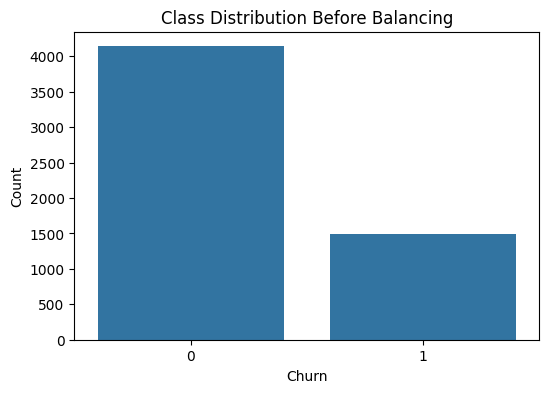

In [285]:
# Visualize before balancing
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [286]:
smote=SMOTE(random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)

y_train_resampled.value_counts()

,count
Churn,
0,4139
1,4139


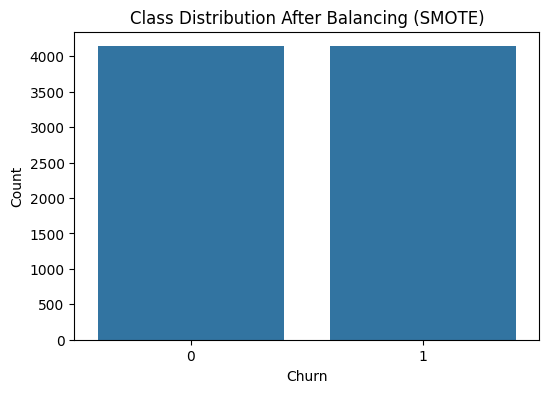

In [287]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution After Balancing (SMOTE)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# **Decision Tree**

In [524]:
#Train decision tree
dt_model=DecisionTreeClassifier(class_weight="balanced",random_state=42)
dt_model.fit(X_train_resampled,y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [525]:
#predict on test set
dt_predict=dt_model.predict(X_test)

In [526]:
#Evaluate the model
print("Accuracy:",accuracy_score(y_test,dt_predict))
print("Precision :",precision_score(y_test,dt_predict))
print("Recall :",recall_score(y_test,dt_predict))
print("F1 Score :",f1_score(y_test,dt_predict))

print("\nClassification Report:\n",classification_report(y_test,dt_predict))

Accuracy: 0.7281760113555713
Precision : 0.49002217294900224
Recall : 0.5909090909090909
F1 Score : 0.5357575757575758

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81      1035
           1       0.49      0.59      0.54       374

    accuracy                           0.73      1409
   macro avg       0.67      0.68      0.67      1409
weighted avg       0.75      0.73      0.74      1409



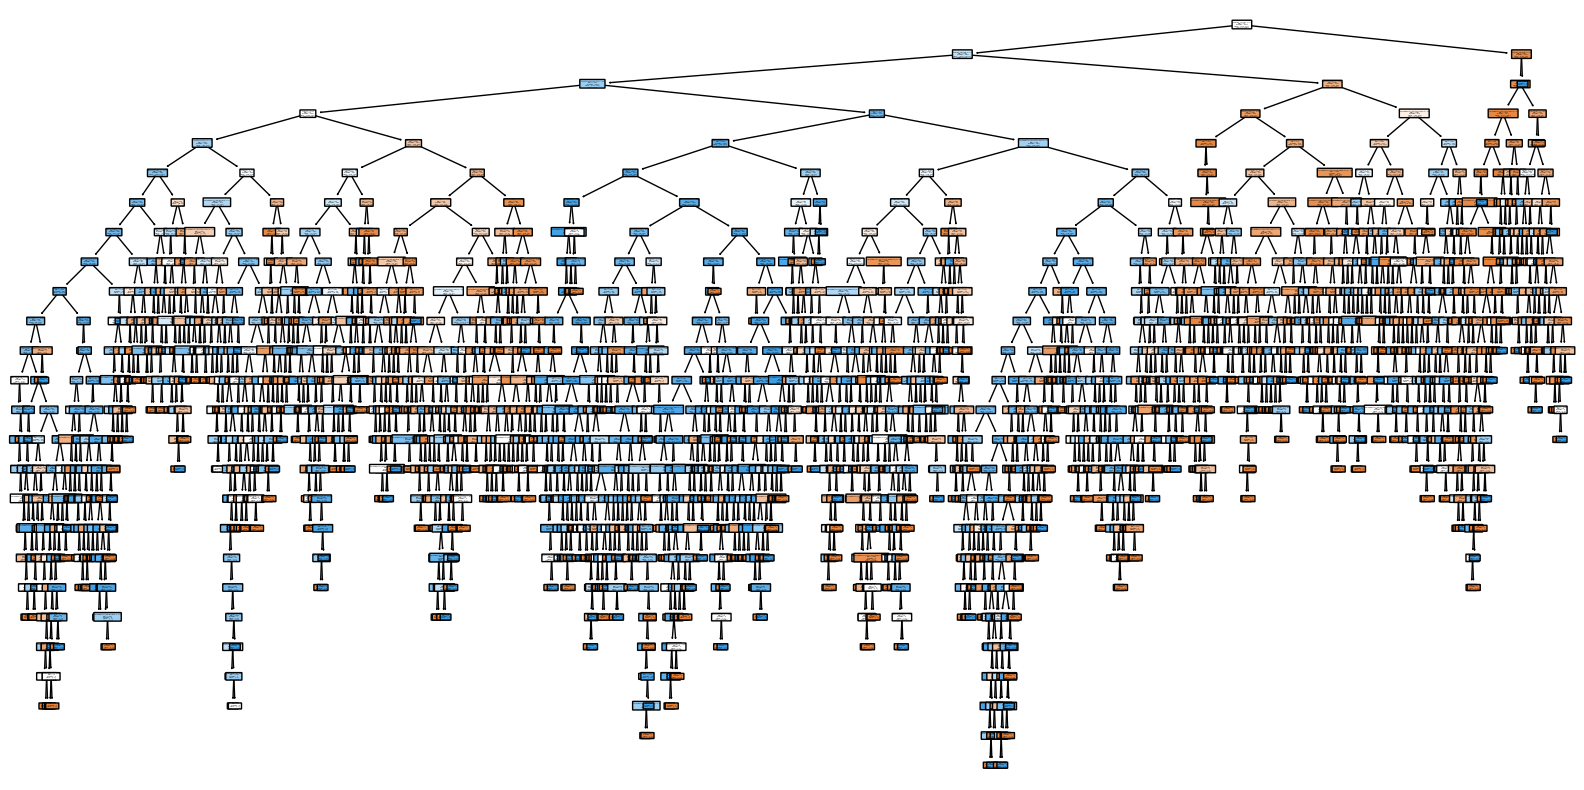

In [533]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Churn','Churn'], filled=True, rounded=True)
plt.show()

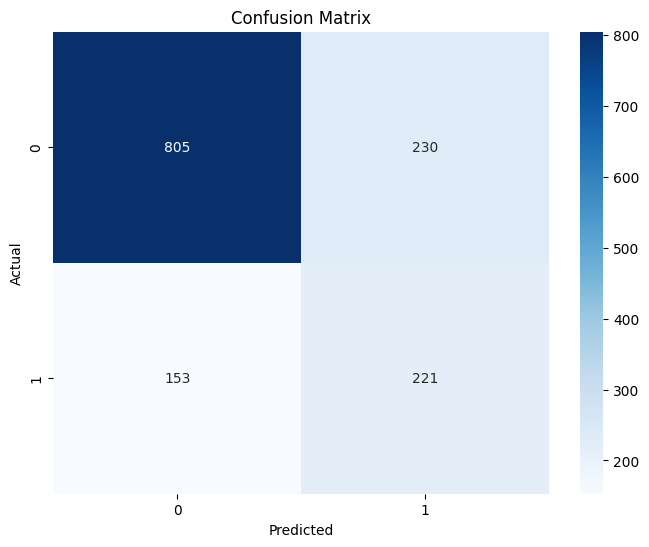

In [301]:
#Confusion Matrix
cm=confusion_matrix(y_test,dt_predict)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [306]:
#Hyperparameter tuning
param_grid={'max_depth':[3,4,5,6],
            'min_samples_split':[10,20,30],
            'min_samples_leaf':[5,10,15],
            'criterion':['gini','entropy']}

dt=DecisionTreeClassifier(random_state=42)

grid_search=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

grid_search.fit(X_train_resampled,y_train_resampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [10, 20, 30]},
             scoring='accuracy')

In [307]:
#Best model
print("Best Parameters : ",grid_search.best_params_)
best_dt=grid_search.best_estimator_

Best Parameters :  {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [308]:
#Evaluate best decision tree
best_predict=best_dt.predict(X_test)

print("Accuracy :",accuracy_score(y_test,best_predict))
print("Precision :",precision_score(y_test,best_predict))
print("Recall :",recall_score(y_test,best_predict))
print("F1 score :",f1_score(y_test,best_predict))

print("\nClassification Report :\n",classification_report(y_test,best_predict))


Accuracy : 0.7487579843860894
Precision : 0.5174825174825175
Recall : 0.7914438502673797
F1 score : 0.6257928118393234

Classification Report :
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



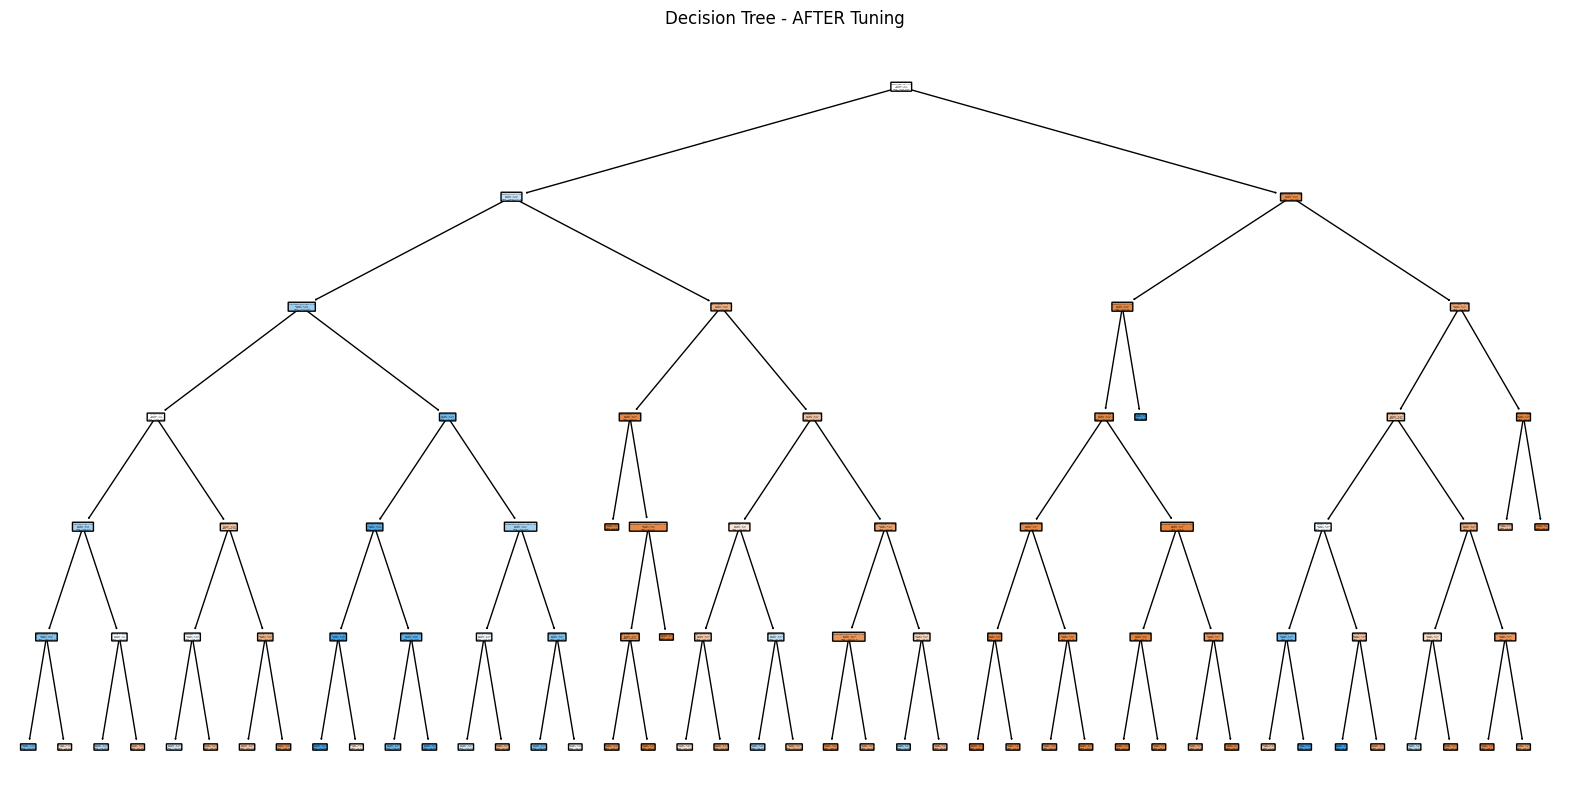

In [529]:
# AFTER tuning
plt.figure(figsize=(20,10))
plot_tree(best_dt,
          feature_names=X.columns,
          class_names=['No Churn','Churn'],
          filled=True, rounded=True)
plt.title("Decision Tree - AFTER Tuning")
plt.show()

In [310]:
train_pred = best_dt.predict(X_train_resampled)
train_acc = accuracy_score(y_train_resampled, train_pred)
print("Training Accuracy:", train_acc)


Training Accuracy: 0.788717081420633


In [311]:
test_pred = best_dt.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print("Testing Accuracy:", test_acc)


Testing Accuracy: 0.7487579843860894


# **Neural Network**

In [511]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Build NN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')   # binary classification
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 192 (768.00 B)

In [512]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_resampled,
    y_train_resampled,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[early_stop],
    batch_size=32,
    verbose=1
)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6823 - loss: 0.6066 - val_accuracy: 0.7119 - val_loss: 0.5271
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7670 - loss: 0.5047 - val_accuracy: 0.7395 - val_loss: 0.5070
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7761 - loss: 0.4779 - val_accuracy: 0.7417 - val_loss: 0.5027
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7746 - loss: 0.4767 - val_accuracy: 0.7431 - val_loss: 0.4986
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7751 - loss: 0.4780 - val_accuracy: 0.7402 - val_loss: 0.5146
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7804 - loss: 0.4695 - val_accuracy: 0.7417 - val_loss: 0.4984
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7946 - loss: 0.4591 - val_accuracy: 0.7523 - val_loss: 0.4971
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7771 - loss: 0.4696 - val_accu

In [513]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [514]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report :\n",classification_report(y_test,y_pred))

Accuracy : 0.752306600425834
Precision: 0.5241779497098646
Recall   : 0.7245989304812834
F1 Score : 0.6083052749719416

Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [515]:
!pip install keras-tuner

In [516]:
def build_model(hp):
    model = Sequential()

    # First layer
    model.add(Dense(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        input_shape=(X_train_resampled.shape[1],)
    ))
    model.add(BatchNormalization())


    # Optional dropout
    model.add(Dropout(hp.Float('dropout_1', 0.0, 0.4, step=0.1)))

    # Second hidden layer
    model.add(Dense(
        units=hp.Int('units_2', min_value=16, max_value=128, step=16),
        activation='relu'
    ))
    model.add(BatchNormalization())


    model.add(Dropout(hp.Float('dropout_2', 0.0, 0.4, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [517]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=30,            # how many models to try
    executions_per_trial=1,
    directory='nn_tuning',
    project_name='telco_churn_nn'
)

Reloading Tuner from nn_tuning/telco_churn_nn/tuner0.json


In [518]:
tuner.search(
    X_train_resampled,
    y_train_resampled,
    epochs=100,
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=1
)

In [519]:
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best units layer1:", best_hps.get('units_1'))
print("Best units layer2:", best_hps.get('units_2'))
print("Best dropout1:", best_hps.get('dropout_1'))
print("Best dropout2:", best_hps.get('dropout_2'))
print("Best learning rate:", best_hps.get('learning_rate'))

Best units layer1: 64
Best units layer2: 112
Best dropout1: 0.1
Best dropout2: 0.1
Best learning rate: 0.01


In [520]:
best_model = tuner.hypermodel.build(best_hps)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

history = best_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7419 - loss: 0.5684 - val_accuracy: 0.7693 - val_loss: 0.4612
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7819 - loss: 0.4709 - val_accuracy: 0.7402 - val_loss: 0.5004
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7867 - loss: 0.4675 - val_accuracy: 0.7473 - val_loss: 0.5036
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7890 - loss: 0.4584 - val_accuracy: 0.7771 - val_loss: 0.4831
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7816 - loss: 0.4574 - val_accuracy: 0.7530 - val_loss: 0.4988
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7964 - loss: 0.4400 - val_accuracy: 0.7452 - val_loss: 0.5050
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7938 - loss: 0.4455 - val_accuracy: 0.7381 - val_loss: 0.5033
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7891 - loss: 0.4498 - val_accu

In [521]:
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report :\n",classification_report(y_test,y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy : 0.7771469127040455
Precision: 0.5717703349282297
Recall   : 0.6390374331550802
F1 Score : 0.6035353535353535

Classification Report :
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1035
           1       0.57      0.64      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409



In [522]:
train_pred = (best_model.predict(X_train_resampled) > 0.5).astype("int32")
train_acc = accuracy_score(y_train_resampled, train_pred)
print("Training Accuracy:", train_acc)

259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step
Training Accuracy: 0.7964484174921479


In [523]:
test_pred = (best_model.predict(X_test) > 0.5).astype("int32")
test_acc = accuracy_score(y_test, test_pred)
print("Testing Accuracy:", test_acc)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing Accuracy: 0.7771469127040455
